<a href="https://colab.research.google.com/github/Mari-iana/interactive-maps-folium/blob/main/%D0%A1%D1%82%D0%B2%D0%BE%D1%80%D0%B5%D0%BD%D0%BD%D1%8F_%D0%BA%D0%B0%D1%80%D1%82%D0%BE%D0%B3%D1%80%D0%B0%D0%BC_%D0%B7%D0%B0_%D0%B4%D0%BE%D0%BF%D0%BE%D0%BC%D0%BE%D0%B3%D0%BE%D1%8E_Python_%D1%82%D0%B0_Folium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вступ / Огляд

Цей Jupyter Notebook містить увесь програмний код до уроку **Підручника цифрової історії** *«Створення картограм за допомогою Python та Folium»* (англ. *Creating Choropleth Maps with Python and Folium*): https://doi.org/10.46430/phen0126

**Обов'язково виконуйте всі комірки коду послідовно!** Під час роботи Jupyter Notebook завантажує дані в оперативну пам'ять комп'ютера в тому порядку, в якому виконуються комірки, а **не** в тому порядку, в якому вони розташовані в документі. Тому, якщо спробувати виконати комірку **№3**, не виконавши попередньо комірку **№2**, код може працювати некоректно або завершитися помилкою.



Імпортуйте бібліотеки, необхідні для уроку.


In [2]:
#!pip install geopandas

import pandas as pd
import geopandas as gpd
import folium
import numpy as np

## Завантаження даних


### Статистика ДТП у Львівській ОТГ

У цьому уроці використовується набір відкритих даних про дорожньо-транспортні пригоди на території Львівської міської територіальної громади. Для забезпечення відтворюваності результатів файл зберігається у відкритому репозиторії GitHub і зчитується безпосередньо за URL-адресою.

Якщо ви бажаєте працювати з локальною копією файлу, попередньо завантажте її до середовища Google Colab (**Files → Upload**), після чого видаліть символ `#` перед відповідним рядком коду та закоментуйте рядок, який зчитує файл із GitHub, поставивши символ `#`.

Якщо у вашому файлі використовується інший роздільник або інша назва стовпця з датою, відповідно змініть параметри `sep` та `parse_dates`.



In [12]:
rta_df = pd.read_csv(
    "https://raw.githubusercontent.com/Mari-iana/interactive-maps-folium/main/data/dtp2024public_Lviv.csv", sep=";", parse_dates=["accidentDate"])
#rta_df = pd.read_csv("dtp2024public_Lviv.csv", sep=";", parse_dates=["accidentDate"])


rta_df.info()

In [13]:
rta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   accidentDate               866 non-null    datetime64[ns]
 1   accidentTime               866 non-null    object        
 2   accidentDay                866 non-null    object        
 3   settlementType             866 non-null    object        
 4   settlement                 866 non-null    object        
 5   district                   866 non-null    object        
 6   streetType                 865 non-null    object        
 7   streetName                 863 non-null    object        
 8   houseNumber                675 non-null    object        
 9   locationComments           118 non-null    object        
 10  accidentType               866 non-null    object        
 11  mainAccidentCause          866 non-null    object        
 12  totalPar

In [15]:
rta_df.sample(5)

,accidentDate,accidentTime,accidentDay,settlementType,settlement,district,streetType,streetName,houseNumber,locationComments,...,injuryStatusParticipant4,injuryStatusParticipant5,injuryStatusParticipant6,injuryStatusParticipant7,injuryStatusParticipant8,injuryStatusParticipant9,injuryStatusParticipant10,injuryStatusParticipant11,latitude,longitude
129,2024-06-16,18:01:00,неділя,місто,Львів,Галицький,вулиця,Насипна,9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.844749,24.032963
492,2024-07-25,14:05:00,четвер,місто,Львів,Шевченківський,проспект,"Чорновола В., просп.",NaN,просп. Чорновола В. - вул. Городоцька,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.856634,24.021070
315,2024-03-21,11:27:00,четвер,місто,Львів,Галицький,вулиця,Городоцька,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.844286,24.025099
98,2024-04-21,12:14:00,неділя,місто,Львів,Личаківський,вулиця,Богданівська,44,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.858685,24.072590
202,2024-06-07,17:37:00,п'ятниця,місто,Львів,Личаківський,вулиця,Чернігівська,79,NaN,...,легко травмований,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.839218,24.045011


In [16]:
rta_df['latitude'].notna()

,latitude
0,True
1,True
2,True
3,True
4,True
...,...
861,True
862,True
863,True
864,True


### Перевірка наявності географічних координат

Для виконання просторового аналізу кожен запис повинен містити координати місця дорожньо-транспортної пригоди. Перевіримо, який відсоток записів має заповнені значення широти (`latitude`) та довготи (`longitude`).



In [18]:
coords_percent = (
    rta_df[["latitude", "longitude"]]
    .dropna()
    .shape[0] / len(rta_df) * 100
)

print(f"{coords_percent:.2f}% записів містять координати.")

100.00% записів містять координати.


Якщо є рядки, в яких вісутня широта чи довгота то виконайте наступну клітинку, попередньо її розкоментувавши
.

In [19]:
# rta_df = rta_df.dropna(subset=["latitude", "longitude"])

### Завантаження геопросторових даних

Завантажте геопросторовий файл, що містить межі територіальних одиниць Львівської об'єднаної територіальної громади.

Перший рядок зчитує файл з репозиторію GitHub. Другий — той самий файл попередньо завантажений до середовища Google Colab.

In [20]:
communities = gpd.read_file( "https://raw.githubusercontent.com/Mari-iana/interactive-maps-folium/main/data/Lviv_district_OTG.geojson"
)
communities = gpd.read_file("Lviv_district_OTG.geojson")

Examine the county geometry data.

In [21]:
communities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   fid         16 non-null     int32   
 1   MOID        16 non-null     object  
 2   ID          16 non-null     object  
 3   NAME        16 non-null     object  
 4   EDITOR_DAT  0 non-null      object  
 5   KOATUU      16 non-null     object  
 6   geometry    16 non-null     geometry
dtypes: geometry(1), int32(1), object(5)
memory usage: 964.0+ bytes


In [22]:
communities.sample(3)

,fid,MOID,ID,NAME,EDITOR_DAT,KOATUU,geometry
4,6,2683390582172157101,14,Малехівська громада,None,4622785701,"MULTIPOLYGON (((24.06764 49.89743, 24.07138 49..."
3,5,2683390582172157100,12,Рясне-Руська громада,None,4625887501,"MULTIPOLYGON (((23.88587 49.84984, 23.88454 49..."
10,12,2105208105154381364,4,Шевченківський район,None,4610137500,"MULTIPOLYGON (((24.0646 49.8784, 24.06433 49.8..."


Для прикладу відобразимо межі Галицького району Львова:

<Axes: >

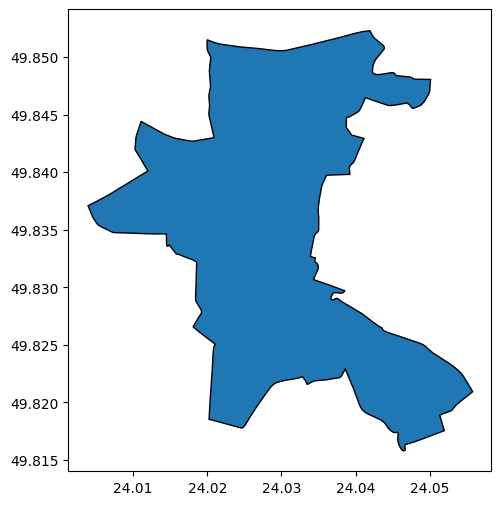

In [23]:
communities[communities["NAME"] == "Галицький район"].plot(
    figsize=(6, 6),
    edgecolor="black"
)

Залишимо лише поля, які будуть потрібні для подальшого аналізу.

GeoDataFrame міститиме ідентифікатор територіальної одиниці (`MOID`), код КОАТУУ (`KOATUU`), її назву (`NAME`) та геометрію (`geometry`).

In [24]:
communities = communities[['MOID','NAME','KOATUU', 'geometry']]
communities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   MOID      16 non-null     object  
 1   NAME      16 non-null     object  
 2   KOATUU    16 non-null     object  
 3   geometry  16 non-null     geometry
dtypes: geometry(1), object(3)
memory usage: 644.0+ bytes


## Підготовка даних до просторового приєднання

Для визначення територіальної одиниці, у межах якої сталася кожна ДТП, необхідно:

- створити точкову геометрію за координатами (`longitude`, `latitude`);
- перетворити таблицю ДТП на GeoDataFrame;
- переконатися, що обидва GeoDataFrame використовують однакову систему координат (`EPSG:4326`).



In [25]:
rta_df["points"] = gpd.points_from_xy(rta_df.longitude, rta_df.latitude, crs="EPSG:4326")

rta_df = gpd.GeoDataFrame(data=rta_df, geometry="points")

In [26]:
communities = communities.to_crs("EPSG:4326")
communities.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Просторове приєднання даних


In [27]:
rta_df = gpd.sjoin(
    rta_df,
    communities,
    how="left",
    predicate="within"
)

Перевіримо GeoDataFrame `rta_df`, щоб переконатися, що просторове приєднання виконано правильно.

In [28]:
rta_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 866 entries, 0 to 865
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   accidentDate               866 non-null    datetime64[ns]
 1   accidentTime               866 non-null    object        
 2   accidentDay                866 non-null    object        
 3   settlementType             866 non-null    object        
 4   settlement                 866 non-null    object        
 5   district                   866 non-null    object        
 6   streetType                 865 non-null    object        
 7   streetName                 863 non-null    object        
 8   houseNumber                675 non-null    object        
 9   locationComments           118 non-null    object        
 10  accidentType               866 non-null    object        
 11  mainAccidentCause          866 non-null    object        
 12  total

In [30]:
rta_df[["accidentDate", "streetName", "NAME", "KOATUU" ]].sample(10)

,accidentDate,streetName,NAME,KOATUU
439,2024-07-23,Зелена,Сихівський район,4610136800
159,2024-06-20,Шевченка Т.,Залізничний район,4610136300
264,2024-03-01,Липинського В.,Шевченківський район,4610137500
397,2024-06-05,Хімічна,Шевченківський район,4610137500
333,2024-05-18,Шевченка Т.,Залізничний район,4610136300
324,2024-05-31,Галицька,Малехівська громада,4622785701
510,2024-07-17,Меретина Б.,Галицький район,4610136600
762,2024-11-03,Сихівська,Сихівський район,4610136800
502,2024-08-13,"Червоної Калини, просп.",Сихівський район,4610136800
299,2024-02-17,"Мазепи І., гетьм.",Шевченківський район,4610137500


## Агрегування даних за адміністративним поділом

Згрупуємо записи про ДТП за кодом КОАТУУ (`KOATUU`) та підрахуємо кількість пригод у кожній територіальній одиниці.

- **`groupby("KOATUU")`** — групує ДТП за територіальними одиницями.
- **`size()`** — підраховує кількість ДТП у кожній територіальній одиниці.
- **`reset_index(name="AccidentCount")`** — перетворює результат у DataFrame та називає стовпець із кількістю ДТП `AccidentCount`.

Отриманий DataFrame міститиме код території та кількість ДТП і буде використаний для побудови картограми.

In [31]:
map_df = (
    rta_df.groupby("KOATUU")
          .size()
          .reset_index(name="AccidentCount")
)

map_df

,KOATUU,AccidentCount
0,4610136300,125
1,4610136600,129
2,4610136800,142
3,4610136900,138
4,4610137200,106
5,4610137500,170
6,4610160300,15
7,4610165500,5
8,4610166300,9
9,4622710200,7


## Ініціалізація базової карти

Створимо базову інтерактивну карту за допомогою функції `initMap()`. Функція визначає картографічну основу, координати центру карти, початковий масштаб та повертає об'єкт `folium.Map`, який надалі використовуватиметься для побудови тематичних карт.

In [44]:
def initMap():
    tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}'
    attr = 'Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community'

    center = [49.84, 24.03]

    map = folium.Map(
        location=center,
        zoom_start=11,
        tiles=tiles,
        attr=attr
    )
    return map

In [45]:
baseMap = initMap()

##Створення картограми

Наступний фрагмент коду створює картограму, яка відображає кількість дорожньо-транспортних пригод у територіальних одиницях Львівської міської територіальної громади.

## Проблема нерівномірного розподілу даних

Чому більшість територіальних одиниць на картограмі мають майже однакове забарвлення?

Для відповіді на це запитання проаналізуємо статистичний розподіл даних.


In [46]:
folium.Choropleth(
    geo_data=communities,
    data=map_df,
    key_on="feature.properties.KOATUU",
    columns=["KOATUU", "AccidentCount"],
    bins=9,
    fill_color="OrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість дорожньо-транспортних пригод"
).add_to(baseMap)

baseMap

In [47]:
map_df.describe()

,AccidentCount
count,16.000000
mean,53.812500
std,66.187832
min,1.000000
25%,2.750000
50%,8.000000
75%,126.000000
max,170.000000


Побудова діаграми розмаху

<Axes: >

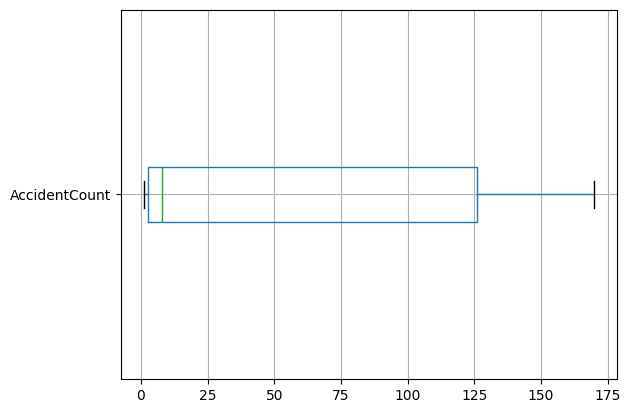

In [50]:
map_df.boxplot(column="AccidentCount", vert=False)

### Спосіб #1 Класифікація методом Фішера—Дженкса

Якщо дані розподілені нерівномірно, рівномірний поділ на інтервали може приховувати важливі просторові відмінності. Алгоритм Фішера—Дженкса (Natural Breaks) автоматично визначає природні межі між класами та формує більш інформативну картограму.

Для використання цього алгоритму в Folium необхідно встановити бібліотеку `jenkspy`, після чого достатньо додати параметр `use_jenks=True` до функції `folium.Choropleth()`.

In [51]:
! pip install jenkspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 11.5 MB/s eta 0:00:00


Тепер, коли бібліотеку `jenkspy` встановлено, ми можемо передати параметр до Folium і перемалювати нашу карту.

In [52]:
baseMap = initMap()

# Якщо карту не ініціалізувати повторно,
# новий тематичний шар буде накладено поверх попереднього.

folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "AccidentCount"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість дорожньо-транспортних пригод за 2024 рік",
    use_jenks=True
).add_to(baseMap)

baseMap


### Спосіб  #2: Використання логарифмічного перетворення



#### Логарифмічне перетворення даних

Для цього використаємо функцію `np.log10()`, яка обчислює десятковий логарифм кількості ДТП та записує результат у новий стовпець `MapScale`.



In [60]:
map_df["MapScale"] = map_df["AccidentCount"].apply(
    lambda x: np.log10(x) if x > 0 else 0
)



Видаліть параметр `use_jenks`, змініть стовпець даних, який потрібно використати для шкали на `MapScale`, а потім перемалюйте карту.

In [61]:
baseMap = initMap()

cp = folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "MapScale"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray"
).add_to(baseMap)

baseMap # this displays the map


Перемалюйте карту, використовуючи код для відображення на шкалі підписів із нелогарифмічними значеннями.

In [62]:
baseMap = initMap()

cp = folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "MapScale"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray"
).add_to(baseMap)

import branca.colormap as cm

# Отримання меж класів, створених Folium
log_value_ticks = cp.color_scale.index

# Видалення стандартної легенди
for key in list(cp._children.keys()):
    if key.startswith("color_map"):
        del cp._children[key]

# Створення нової легенди
min_value = round(10 ** log_value_ticks[0])
max_value = round(10 ** log_value_ticks[-1])

colormap = cm.linear.YlOrRd_09.scale(min_value, max_value)

# Формування підписів легенди у вихідних значеннях
tick_values = [round(10 ** x) for x in log_value_ticks]
colormap.custom_ticks = tick_values

colormap.caption = "Кількість дорожньо-транспортних пригод"

colormap.add_to(baseMap)

baseMap

## Normalizing the Data




### Завантаження даних про чисельність населення

Файл можна прочитати аналогічно до попередніх прикладів


In [63]:
pop_df = pd.read_csv(
    "https://raw.githubusercontent.com/Mari-iana/interactive-maps-folium/main/data/Population_Lviv.csv",
    sep=";"
)


In [65]:
pop_df.info()
pop_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   MOID        16 non-null     object
 1   NAME        16 non-null     object
 2   POPULATION  16 non-null     int64 
 3   KOATUU      16 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 644.0+ bytes


,MOID,NAME,POPULATION,KOATUU
0,"2,68339E+18",Рудненська громада,6522,4610165500
1,"2,68339E+18",Винниківська громада,15723,4610160300
2,"2,68339E+18",Брюховицька громада,5772,4610166300
3,"2,68339E+18",Рясне-Руська громада,2161,4625887501
4,"2,68339E+18",Малехівська громада,2336,4622785701


### Підготовка даних

Перевіримо тип колонок у обох DataFrame.

In [67]:
print(map_df["KOATUU"].dtype)
print(pop_df["KOATUU"].dtype)

object
int64


In [68]:
print(map_df["KOATUU"].head())
print(pop_df["KOATUU"].head())

0    4610136300
1    4610136600
2    4610136800
3    4610136900
4    4610137200
Name: KOATUU, dtype: object
0    4610165500
1    4610160300
2    4610166300
3    4625887501
4    4622785701
Name: KOATUU, dtype: int64


Обидва стовпці перетворимо на тип string

In [69]:
map_df["KOATUU"] = map_df["KOATUU"].astype(str)
pop_df["KOATUU"] = pop_df["KOATUU"].astype(str)

### Додайте дані про чисельність населення до датафрейму **map_df**.

Після приведення типів даних до одного формату можна об'єднати таблиці за допомогою методу merge().

In [70]:
map_df = map_df.merge(
    pop_df,
    on="KOATUU"
)
map_df.head()

,KOATUU,AccidentCount,MapScale,MOID,NAME,POPULATION
0,4610136300,125,2.096910,"2,10521E+18",Залізничний район,132000
1,4610136600,129,2.110590,"2,10521E+18",Галицький район,67000
2,4610136800,142,2.152288,"2,10521E+18",Сихівський район,165000
3,4610136900,138,2.139879,"2,10521E+18",Франківський район,182000
4,4610137200,106,2.025306,"2,10521E+18",Личаківський район,94000


In [71]:
map_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   KOATUU         16 non-null     object 
 1   AccidentCount  16 non-null     int64  
 2   MapScale       16 non-null     float64
 3   MOID           16 non-null     object 
 4   NAME           16 non-null     object 
 5   POPULATION     16 non-null     int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 900.0+ bytes


## Обчислення відносного показника

Для коректного порівняння територіальних одиниць обчислимо кількість дорожньо-транспортних пригод на 10 000 жителів.

Новий показник буде збережено у стовпці `AccidentsPer10000` і використано для побудови картограми.

In [73]:
map_df["AccidentsPer10000"] = (map_df["AccidentCount"] / (map_df["POPULATION"] / 10000))

map_df.head()

,KOATUU,AccidentCount,MapScale,MOID,NAME,POPULATION,AccidentsPer10000
0,4610136300,125,2.096910,"2,10521E+18",Залізничний район,132000,9.469697
1,4610136600,129,2.110590,"2,10521E+18",Галицький район,67000,19.253731
2,4610136800,142,2.152288,"2,10521E+18",Сихівський район,165000,8.606061
3,4610136900,138,2.139879,"2,10521E+18",Франківський район,182000,7.582418
4,4610137200,106,2.025306,"2,10521E+18",Личаківський район,94000,11.276596


## Побудова картограми за нормалізованими даними

In [74]:
baseMap = initMap()

folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "AccidentsPer10000"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість ДТП на 10 000 жителів"
).add_to(baseMap)

baseMap

## Аналіз нормалізованих даних

Після нормалізації перевіримо, як змінився статистичний розподіл показника. Для цього використаємо метод `describe()`, який обчислює основні описові характеристики даних.


In [75]:
map_df["AccidentsPer10000"].describe()

,AccidentsPer10000
count,16.000000
mean,10.501798
std,5.679282
min,4.173623
25%,7.170619
50%,9.362336
75%,11.806017
max,25.684932


<Axes: >

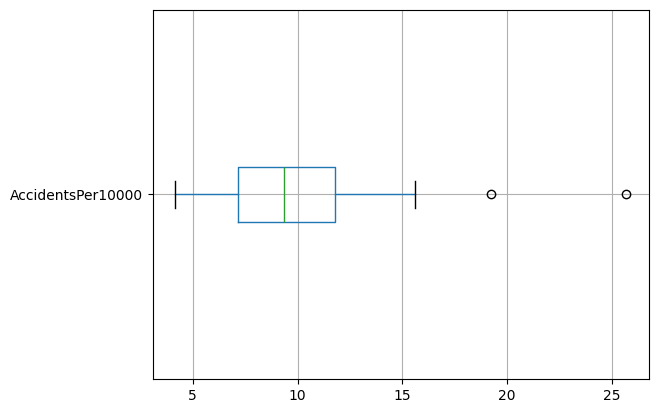

In [76]:
map_df.boxplot(column=["AccidentsPer10000"], vert=False)

## Покращення карти

### Додавання плаваючого інформаційного поля

Цей код оманливо простий. Дивіться урок для опису того, що відбувається.

In [78]:
baseMap = initMap()

cp = folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "AccidentsPer10000"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість ДТП на 10 000 жителів"
  ).add_to(baseMap)

map_data_lookup = map_df.set_index("KOATUU")

for row in cp.geojson.data['features']:
  try:
      row['properties']['AccidentCount'] = f"{(map_data_lookup.loc[row['properties']['KOATUU'],'AccidentCount']):.0f}"
  except KeyError:
      row['properties']['AccidentCount'] = 'Не відбулось жодної ДТП'

folium.GeoJsonTooltip(['NAME','AccidentCount'],aliases=['Громада:','Випадків ДТП:']).add_to(cp.geojson)

baseMap

Складніший приклад плаваючого інформаційного вікна, що відображає кілька змінних.

In [80]:
baseMap = initMap()

cp = folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "AccidentsPer10000"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість ДТП на 10 000 жителів"
  ).add_to(baseMap)

map_data_lookup = map_df.set_index("KOATUU")

for row in cp.geojson.data['features']:
  try:
      row['properties']['AccidentCount'] = f"{(map_data_lookup.loc[row['properties']['KOATUU'],'AccidentCount']):.0f}"
  except KeyError:
      row['properties']['AccidentCount'] = 'Не відбулось жодної ДТП'
  try:
      row['properties']['AccidentsPer10000'] = f"{map_data_lookup.loc[row['properties']['KOATUU'],'AccidentsPer10000']:.2f}"
  except KeyError:
      row['properties']['AccidentsPer10000'] = 'No data'
  try:
      row['properties']['POPULATION'] = f"{map_data_lookup.loc[row['properties']['KOATUU'],'POPULATION']:,.0f}"
  except KeyError:
      row['properties']['POPULATION'] = 'No data'

folium.GeoJsonTooltip(['NAME','POPULATION','AccidentCount','AccidentsPer10000'],
                      aliases=['Громада:', 'Населення:', 'Випадків ДТП:',
                               'Випадків ДТП на 10 000 жителів:' ]).add_to(cp.geojson)

baseMap

### Додавання карти-врізки


In [81]:
from folium import plugins
minimap = plugins.MiniMap()
baseMap.add_child(minimap)

baseMap

### Додавання заголовку
Додавання заголовку до карти Folium.



In [87]:
baseMap = initMap()

titleText = """Кількість ДТП у Львівській ОТГ за 2024 рік"""
title_html = '''
             <h4 align="center" style="font-size:16px"><b>{}</b></h4>
             '''.format(titleText)
baseMap.get_root().html.add_child(folium.Element(title_html))

cp = folium.Choropleth(
    geo_data=communities,
    data=map_df,
    columns=["KOATUU", "AccidentsPer10000"],
    key_on="feature.properties.KOATUU",
    bins=9,
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Кількість ДТП на 10 000 жителів"
  ).add_to(baseMap)

map_data_lookup = map_df.set_index("KOATUU")

for row in cp.geojson.data['features']:
  try:
      row['properties']['AccidentCount'] = f"{(map_data_lookup.loc[row['properties']['KOATUU'],'AccidentCount']):.0f}"
  except KeyError:
      row['properties']['AccidentCount'] = 'Не відбулось жодної ДТП'
  try:
      row['properties']['AccidentsPer10000'] = f"{map_data_lookup.loc[row['properties']['KOATUU'],'AccidentsPer10000']:.2f}"
  except KeyError:
      row['properties']['AccidentsPer10000'] = 'No data'
  try:
      row['properties']['POPULATION'] = f"{map_data_lookup.loc[row['properties']['KOATUU'],'POPULATION']:,.0f}"
  except KeyError:
      row['properties']['POPULATION'] = 'No data'

folium.GeoJsonTooltip(['NAME','POPULATION','AccidentCount','AccidentsPer10000'],
                      aliases=['Громада:', 'Населення:', 'Випадків ДТП:',
                               'Випадків ДТП на 10 000 жителів:' ]).add_to(cp.geojson)

baseMap

## Зберігання карти

Збереження карти як HTML файлу.

In [88]:
baseMap.save('AccidentAnalysisMap.html')